# Does Size Matter? Exploring the Impact of Batch Size on Deep Learning Performance

<img src="https://pbs.twimg.com/media/GBDz4Y0XMAACbj8.jpg" alt="Batch Size Illustration" width="450">


## What is Batch Size?

In deep learning, batch size refers to the number of training examples used to compute one update to the model’s weights during training.

Instead of updating weights after every single data point (stochastic) or after processing the entire dataset (full batch), we typically train using mini-batches.

In **mini-batch gradient descent**, the training data is divided into small batches:

$$
w_{t+1} = w_t - \eta \cdot \frac{1}{m} \sum_{i=1}^{m} \nabla L_i(w_t)
$$


where:
- $ w_t $ = model parameters at iteration \( t \)
- $ \eta $ = learning rate
- $ m $ = batch size
- $ \nabla L_i(w_t) $ = gradient of the loss for the \( i^{th} \) sample in the batch

---

## Purpose in Training Deep Learning Models

Batch size controls the trade-off between stability and efficiency during optimization:

| Batch Size                  | Characteristics            | Pros                  | Cons                        |
| --------------------------- | -------------------------- | --------------------- | --------------------------- |
| **Small (e.g., 16–64)**     | Noisy gradient updates     | Better generalization | Slower convergence          |
| **Medium (e.g., 128–256)**  | Balanced updates           | Good trade-off        | Requires moderate memory    |
| **Large (e.g., 512–1024+)** | Stable but less stochastic | Faster training       | Risk of poor generalization |

---

## Theoretical Effect on Model Performance

**Small batches** (e.g., 16–64 samples) introduce more randomness in the gradient estimates because each batch is only a small subset of the dataset. This stochasticity can help the model escape shallow or poor local minima during training, potentially leading to better overall generalization on unseen data. However, the noisy updates may slow convergence and produce oscillations in the loss curve. Small batches are particularly useful for small to medium-sized datasets where generalization is more important than raw speed.

**Large batches** (e.g., 128–512 samples) produce smoother, more accurate gradient estimates because they average over a larger number of samples. This reduces the noise in updates, allowing the optimizer to make stable, consistent progress toward a minimum. Training is generally faster per epoch due to parallelization, but there is a risk that the model converges to sharp minima—narrow regions in the loss landscape—which may generalize less well to unseen data. Large batches are often used in large-scale datasets where computational efficiency is critical.

**Extremely large batches** (full-batch gradient descent) behave almost like deterministic gradient descent, where the gradient is computed over the entire dataset. This produces very smooth updates but removes almost all stochasticity, which can cause the model to get stuck in poor local minima. Extremely large batches often require learning rate scaling (e.g., linear scaling rule) or gradient accumulation strategies to maintain stable and effective training. While this approach can be computationally efficient, it may reduce the model’s ability to generalize compared to smaller, more stochastic batches.

---

## Experiment Setup

**Dataset:** FashionMNIST  
**Model:** Simple CNN  
**Optimizer:** Adam (`lr = 0.001`)  
**Variable:** Batch size ∈ {16, 64, 256}  
**Epochs:** 5  
**Metrics:** Training Loss, Accuracy, Runtime  

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

### Dataset

In [3]:
from torchvision.datasets import FashionMNIST

transform = transforms.Compose([transforms.ToTensor()])

trainset = FashionMNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
testset = FashionMNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [15:03<00:00, 29.2kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:01<00:00, 25.7kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [02:52<00:00, 25.7kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:01<00:00, 3.32kB/s]


### Model

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

### Training Function

In [5]:
def train_model(batch_size):
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)
    
    model = SimpleCNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_loss, train_acc = [], []
    start_time = time.time()
    
    for epoch in range(5):
        correct, total, running_loss = 0, 0, 0.0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss.append(running_loss / len(trainloader))
        train_acc.append(100 * correct / total)
    
    runtime = time.time() - start_time
    return train_loss, train_acc, runtime

### Experiment

In [6]:
batch_sizes = [16, 64, 256]
results = {bs: train_model(bs) for bs in batch_sizes}

### Plot Loss

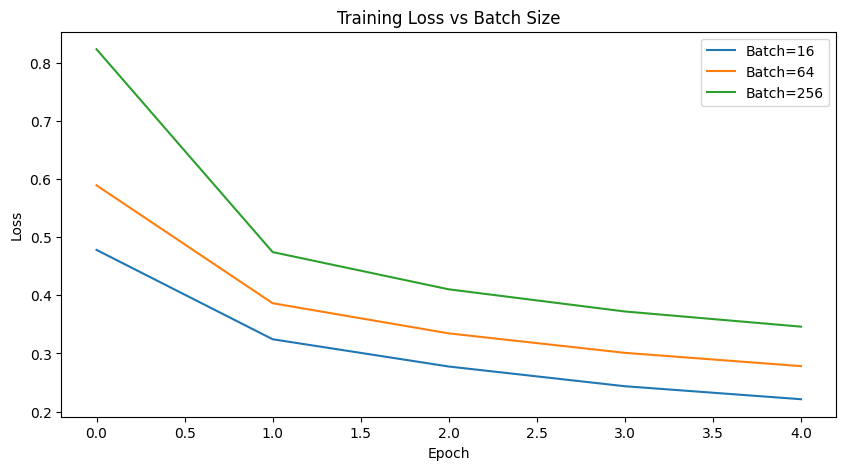

In [7]:
plt.figure(figsize=(10,5))
for bs in batch_sizes:
    plt.plot(results[bs][0], label=f'Batch={bs}')
plt.title('Training Loss vs Batch Size')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1. Smaller batch sizes achieve consistently lower training loss

Smaller batches introduce more noise in gradient updates, which often leads to better generalization and faster convergence. The model trained with batch size 16 learns more effectively, reflected in its lower loss trend.

2. Larger batch sizes converge more slowly

Large batch sizes produce smoother gradients, but this can slow down optimization. The model becomes less responsive to small patterns in the data, leading to slower training progress.

3. All batch sizes show improvement over epochs

The training process is working, but the efficiency of learning depends heavily on batch size.

4. Diminishing improvements at later epochs

This is typical in training curves where early epochs capture large-scale patterns. While later epochs fine-tune smaller details, resulting in slower loss reduction.

### Plot Accuracy

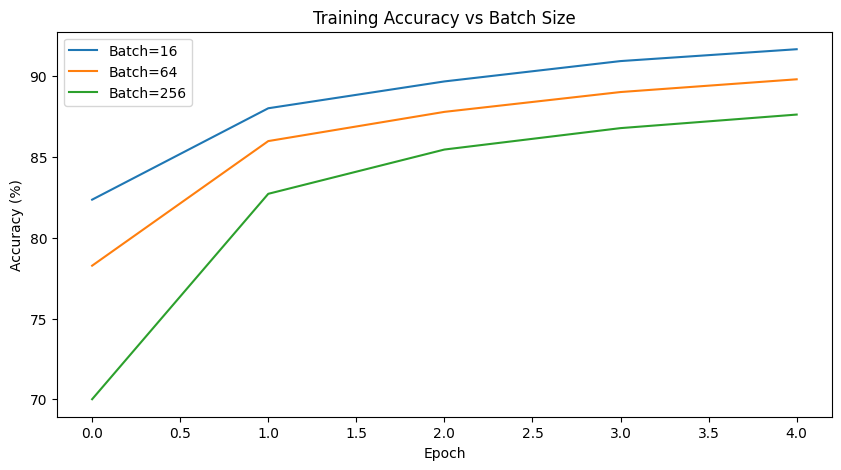

In [8]:
plt.figure(figsize=(10,5))
for bs in batch_sizes:
    plt.plot(results[bs][1], label=f'Batch={bs}')
plt.title('Training Accuracy vs Batch Size')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

1. Smaller batch sizes yield higher accuracy

This mirrors the loss graph: smaller batches lead to better optimization and better generalization by introducing noise in gradient calculations. This noise acts like a regularizer, improving learning efficiency.

2. Accuracy improves steadily across all batch sizes

This confirms that regardless of batch size, the model is learning meaningful patterns. Early epochs capture core structure, while later epochs refine details.

3. Performance gap widens between small and large batch sizes

Large batches converge more slowly and tend to generalize slightly worse. Even with more epochs, they rarely catch up to small-batch performance.

4. Batch 256 has the slowest improvement

Large batches produce smoother gradients, which slows adaptation to the data’s complexity. The model becomes more stable—but less flexible—during training.

### Plot Runtime Summary

In [9]:
for bs in batch_sizes:
    print(f"Batch Size {bs}: Runtime = {results[bs][2]:.2f} sec, Final Acc = {results[bs][1][-1]:.2f}%")

Batch Size 16: Runtime = 232.77 sec, Final Acc = 91.66%
Batch Size 64: Runtime = 161.03 sec, Final Acc = 89.80%
Batch Size 256: Runtime = 142.28 sec, Final Acc = 87.62%


---

## Results and Analysis

| Batch Size | Final Accuracy | Training Runtime (sec) | Behavior and Interpretation                                                                                                                                                                                                                                                                                                                                                              |
| ---------- | -------------- | ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **16**     | **91.66%**     | **232.77**             | Small batches introduce high gradient noise, which helps the optimizer escape sharp local minima and explore the loss landscape more effectively. This often leads to **flatter minima**, which are strongly correlated with better generalization. However, the stochasticity increases computation time since more parameter updates occur per epoch.                                  |
| **64**     | **89.80%**     | **161.03**             | Medium-sized batches strike a balance between stability and stochasticity. They provide smoother gradient estimates that accelerate convergence while retaining some regularizing noise. This batch size typically represents a good compromise—fast enough to train efficiently, but still capable of avoiding overly sharp minima.                                                     |
| **256**    | **87.62%**     | **142.28**             | Large batches produce almost deterministic gradient updates, reducing training variance significantly. While this speeds up training, the optimizer tends to converge to **sharper minima**, which are known to generalize poorly. Large batches often require techniques like **learning rate warmup, gradient accumulation, or linear scaling** to avoid degradation in model quality. |



### Performance of Small Batch Size (Batch = 16)

The model trained with a batch size of 16 achieves the highest accuracy at 91.66% but also requires the longest runtime at 232.77 seconds. This behavior is expected because small batches introduce higher gradient noise, which helps the optimizer escape sharp local minima and explore the loss landscape more effectively. The added stochasticity encourages convergence toward flatter minima—solutions that generalize better to unseen data. Although this results in slower training due to more frequent parameter updates, the improved generalization performance makes small batches advantageous when accuracy is the primary goal.

### Behavior of Medium Batch Size (Batch = 64)

Using a batch size of 64 yields a final accuracy of 89.80% with a noticeably shorter runtime of 161.03 seconds. This configuration strikes a balance between the instability of small batches and the determinism of large batches. The gradients are smoother and more stable than those of batch size 16, allowing for faster convergence, yet still contain enough noise to prevent the optimizer from falling into overly sharp minima. As a result, batch size 64 provides a practical compromise when both training efficiency and model performance are important considerations.

### Limitations of Large Batch Size (Batch = 256)

The largest batch size, 256, produces the fastest training time at 142.28 seconds but the lowest accuracy at 87.62%. Large batches dramatically reduce gradient variance, making the optimization path more rigid and limiting the model’s ability to explore different regions of the loss surface. This often leads to convergence toward sharp minima that fit the training data well but fail to generalize effectively. Without additional techniques such as learning rate scaling or warm-up schedules, large-batch training tends to underperform in terms of accuracy, as reflected in these results.

### Overall Interpretation and Trade-offs

Across all batch sizes, a clear trade-off emerges: larger batches significantly accelerate training but consistently degrade model performance. Smaller batches, though computationally more expensive, benefit from the implicit regularization created by gradient noise, guiding the optimizer toward flatter and more robust minima. Conversely, very large batches produce smoother but less flexible gradient updates, which restrict exploration and increase the risk of converging to narrow, less generalizable solutions. These outcomes align with established deep learning theory and highlight that the optimal batch size depends on the objective—accuracy favors smaller batches, while efficiency favors larger ones.


---

## Insights for Future Model Tuning

This experiment shows that batch size directly affects the balance between speed and generalization. Smaller batches yield better generalization due to gradient noise, while larger batches train faster but risk poorer minima. Choosing an optimal batch size is a key step in hyperparameter tuning for deep learning.

- For small datasets, small or medium batches (16–128) tend to generalize better.

- For large-scale datasets, larger batches improve computational efficiency.

- Combine with learning rate scaling or gradient accumulation to maintain stability.

- Always visualize loss curves — noisy curves suggest smaller batches, smooth curves larger ones.

---

> So, to answer the question **“Does size matter?”**—absolutely. The choice of batch size fundamentally shapes how a deep learning model learns, what kinds of solutions it converges to, and how well it performs in the real world. Smaller batches encourage richer exploration and stronger generalization, while larger batches prioritize speed at the expense of robustness. In the end, batch size is not just a computational detail—it is a strategic decision that directly determines the balance between efficiency and accuracy in deep learning performance.

## References

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

- Keskar, N. S., et al. (2017). On Large-Batch Training for Deep Learning: Generalization Gap and Sharp Minima. ICLR.

- PyTorch Official Tutorials: https://pytorch.org/tutorials/